In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw.csv')

df.shape
display(df.head())
df.info()
df.isnull().sum()


,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63,1,True,True,True,Shahran,1.850000e+09,61666.67
1,60,1,True,True,True,Shahran,1.850000e+09,61666.67
2,79,2,True,True,True,Pardis,5.500000e+08,18333.33
3,95,2,True,True,True,Shahrake Qods,9.025000e+08,30083.33
4,123,2,True,True,True,Shahrake Gharb,7.000000e+09,233333.33


<class 'pandas.DataFrame'>
RangeIndex: 3479 entries, 0 to 3478
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Area        3479 non-null   str    
 1   Room        3479 non-null   int64  
 2   Parking     3479 non-null   bool   
 3   Warehouse   3479 non-null   bool   
 4   Elevator    3479 non-null   bool   
 5   Address     3456 non-null   str    
 6   Price       3479 non-null   float64
 7   Price(USD)  3479 non-null   float64
dtypes: bool(3), float64(2), int64(1), str(2)
memory usage: 146.2 KB


Area           0
Room           0
Parking        0
Warehouse      0
Elevator       0
Address       23
Price          0
Price(USD)     0
dtype: int64

Convert 'Area' from str to number.

In [2]:
# Check the actual data types in the column
print(df['Area'].apply(type).value_counts())

# Clean string values (if commas exist) and convert to numeric
df['Area'] = df['Area'].astype(str).str.replace(',', '').str.strip()
df['Area'] = pd.to_numeric(df['Area'], errors='coerce')

print("Number of rows with conversion errors (NaN):", df['Area'].isnull().sum())
df = df.dropna(subset=['Area'])

Area
<class 'str'>    3479
Name: count, dtype: int64
Number of rows with conversion errors (NaN): 0


In [3]:
# Remove rows with clearly invalid Area values
# (unrealistically large values, e.g., in the billions, which are not plausible for house area)
print("Number of rows with Area > 10,000:", (df['Area'] > 10000).sum())
df = df[df['Area'] <= 10000]

Number of rows with Area > 10,000: 4


In [4]:
print("Number of rows with Area > 2,000:", (df['Area'] > 2000).sum())
df = df[df['Area'] <= 2000]

df['Area'].describe()

Number of rows with Area > 2,000: 1


count    3474.000000
mean      107.031664
std        70.991973
min        30.000000
25%        69.000000
50%        90.000000
75%       120.000000
max      1000.000000
Name: Area, dtype: float64

Data has some outlier value in area, it affect the plot that will
be drawn in the next step, so i choose to delete them.

In [5]:
print(df[['Price', 'Price(USD)']].corr())
df = df.drop(columns=['Price'])

# Change the name for easier operation
df = df.rename(columns={'Price(USD)': 'Price_USD'})
target = 'Price_USD'

            Price  Price(USD)
Price         1.0         1.0
Price(USD)    1.0         1.0


Classification based on data format

In [6]:
numeric_cols = ['Area', 'Room']
numeric_cols_log = ['Area_log', 'Room']   # Used when training the model with the log-transformed version
boolean_cols = ['Parking', 'Warehouse', 'Elevator']
categorical_cols = ['Address']

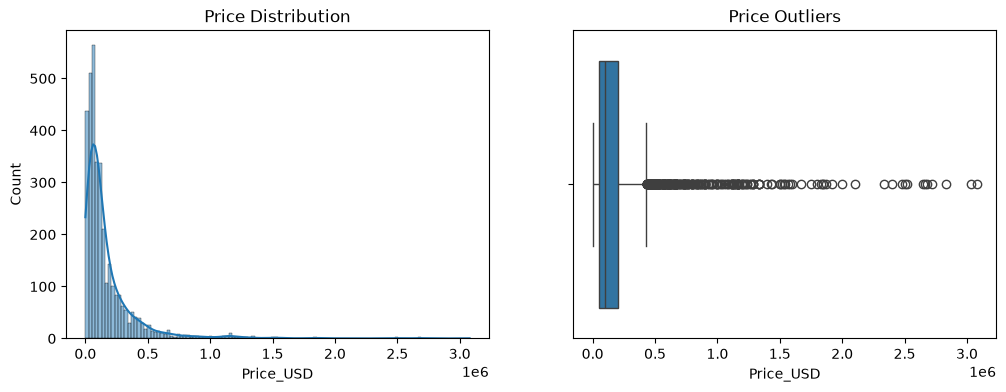

Skewness: 4.78136064205584


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df[target], kde=True, ax=axes[0])
axes[0].set_title('Price Distribution')

sns.boxplot(x=df[target], ax=axes[1])
axes[1].set_title('Price Outliers')

plt.show()

print("Skewness:", df[target].skew())

The distribution of the target variable is heavily right-skewed, indicating the presence of a small number of extremely high price values. These extreme values can negatively affect the training process, particularly for linear regression models. Therefore, we apply a log transformation to reduce the skewness, stabilize the variance, and make the distribution more closely resemble a normal distribution.

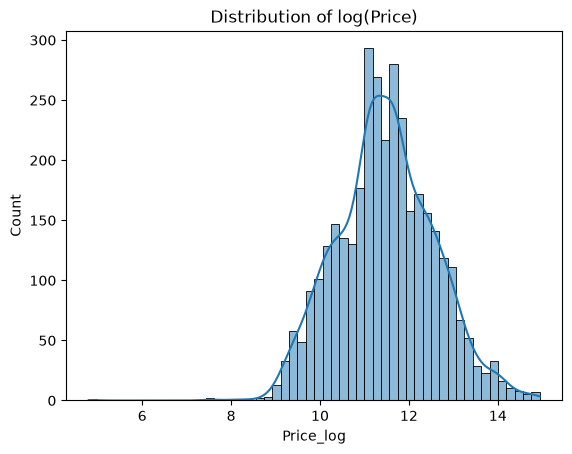

In [8]:
df['Price_log'] = np.log1p(df[target])

sns.histplot(df['Price_log'], kde=True)
plt.title('Distribution of log(Price)')
plt.show()

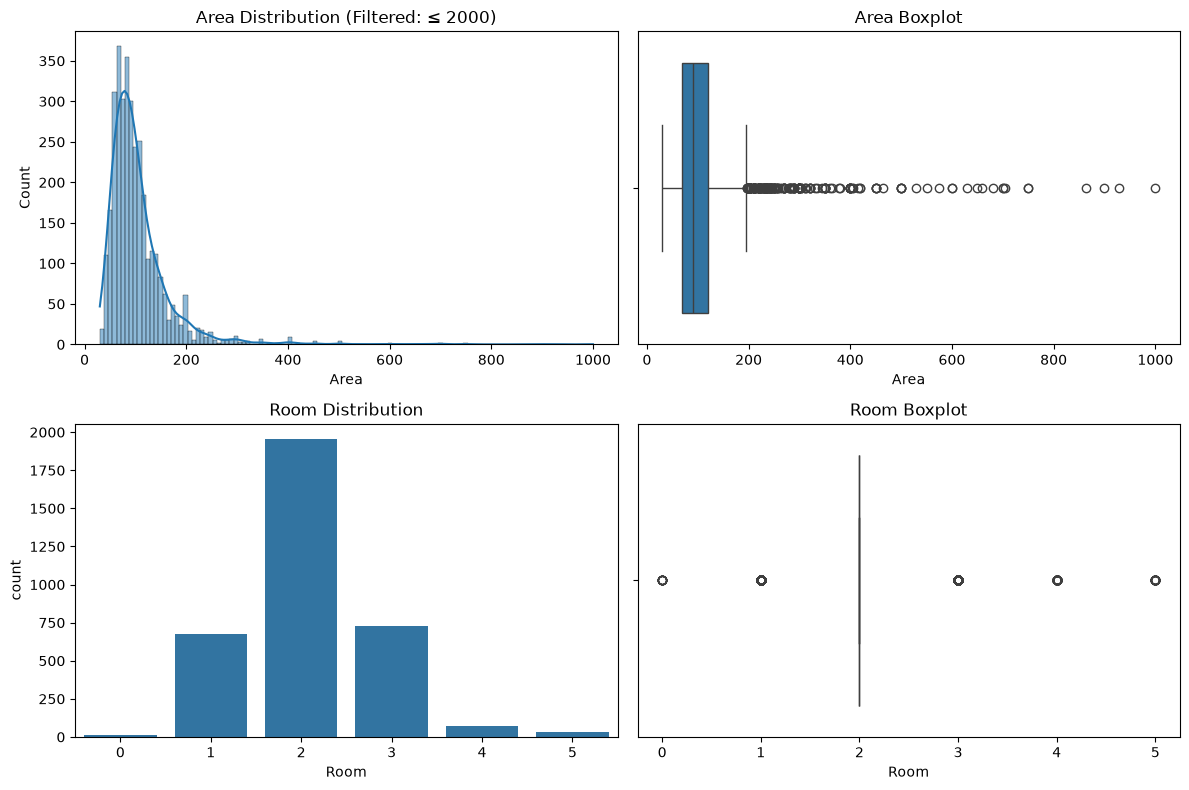

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df['Area'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Area Distribution (Filtered: ≤ 2000)')

sns.boxplot(x=df['Area'], ax=axes[0, 1])
axes[0, 1].set_title('Area Boxplot')

sns.countplot(x='Room', data=df, ax=axes[1, 0])
axes[1, 0].set_title('Room Distribution')

sns.boxplot(x=df['Room'], ax=axes[1, 1])
axes[1, 1].set_title('Room Boxplot')

plt.tight_layout()
plt.show()

The distribution of Area remains heavily right-skewed, even after removing the majority of extreme values. Therefore, a log transformation will also be applied to this feature to reduce skewness and improve its distribution for model training.

The Room feature is highly concentrated around 2 rooms, causing the boxplot to appear almost like a single line. However, the remaining values are not considered outliers, as they represent valid and realistic observations. Therefore, no additional filtering is performed on this feature.

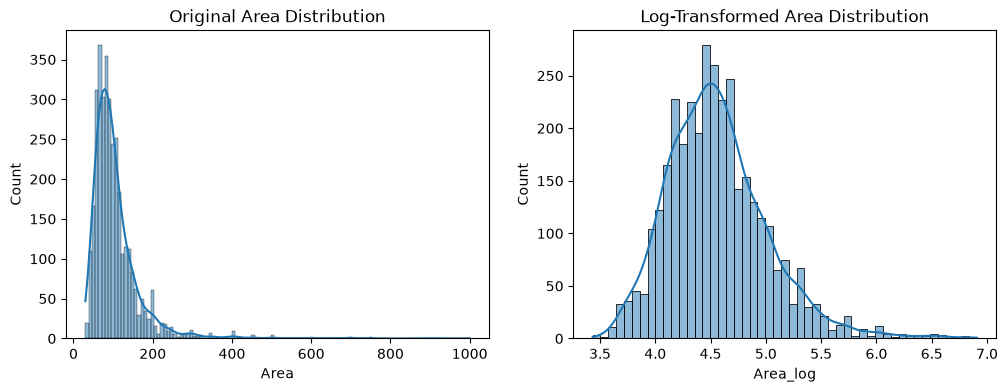

Original Area Skewness: 4.759417912983609
Log-Transformed Area Skewness: 0.8962004917152792


In [10]:
df['Area_log'] = np.log1p(df['Area'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['Area'], kde=True, ax=axes[0])
axes[0].set_title('Original Area Distribution')

sns.histplot(df['Area_log'], kde=True, ax=axes[1])
axes[1].set_title('Log-Transformed Area Distribution')

plt.show()

print("Original Area Skewness:", df['Area'].skew())
print("Log-Transformed Area Skewness:", df['Area_log'].skew())

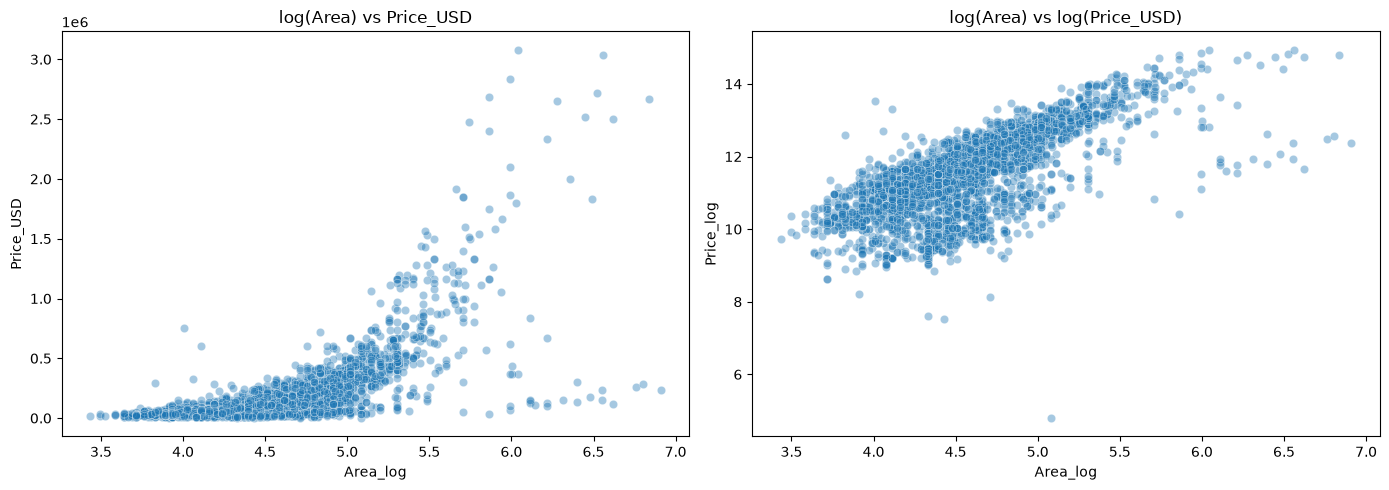

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.scatterplot(x='Area_log', y=target, data=df, alpha=0.4, ax=axes[0])
axes[0].set_title('log(Area) vs Price_USD')

sns.scatterplot(x='Area_log', y='Price_log', data=df, alpha=0.4, ax=axes[1])
axes[1].set_title('log(Area) vs log(Price_USD)')
plt.tight_layout()
plt.show()

After applying the log transformation to Price and Area—the two most highly skewed features—we obtain much more balanced distributions. Both log(Price) and log(Area) are now better suited for training a linear regression model.

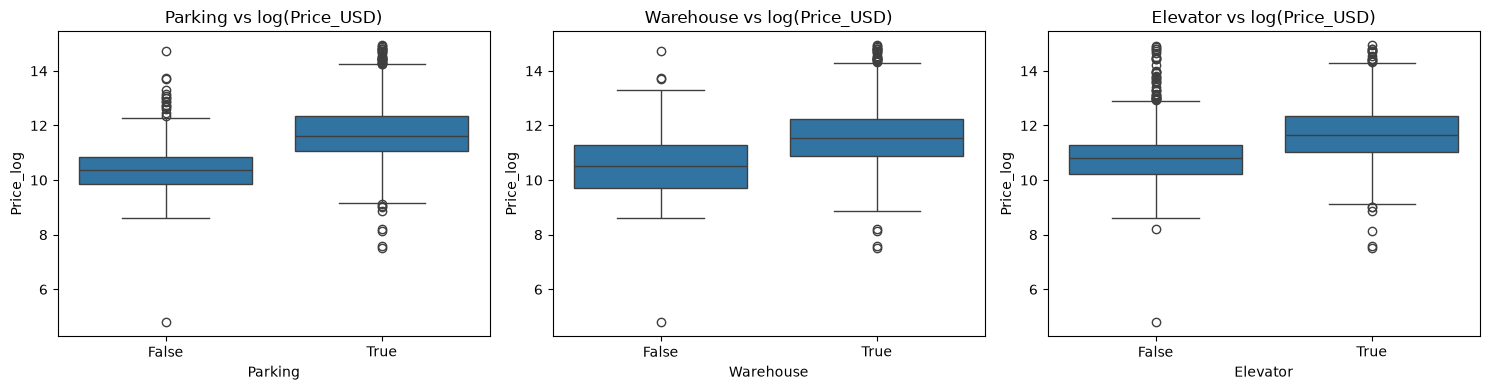

Parking
False    10.414249
True     11.666910
Name: Price_log, dtype: float64

Warehouse
False    10.588383
True     11.559244
Name: Price_log, dtype: float64

Elevator
False    10.881705
True     11.637243
Name: Price_log, dtype: float64



In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, boolean_cols):
    sns.boxplot(x=col, y='Price_log', data=df, ax=ax)
    ax.set_title(f'{col} vs log(Price_USD)')
plt.tight_layout()
plt.show()

for col in boolean_cols:
    print(df.groupby(col)['Price_log'].mean())
    print()

Strong Positive Relationship: All three amenity features (Parking, Warehouse, and Elevator) show a clear positive association with house prices. The median log-transformed price for properties with each amenity (True) is consistently around 1 to 1.5 units higher than for properties without it (False), indicating that these amenities are associated with higher property values.

Good Group Separation: The interquartile ranges (IQRs) of the True and False groups are well separated with relatively little overlap. This suggests that the price differences between the groups are systematic rather than the result of random variation.

Implications for Linear Regression: Applying the log transformation to the target variable results in more comparable variances across the groups, as reflected by the similar box sizes. Given their strong separation and clear relationship with the target, these three features are expected to have high predictive value and are likely to receive relatively large coefficients in the linear regression model, contributing positively to its predictive performance (e.g., R²).

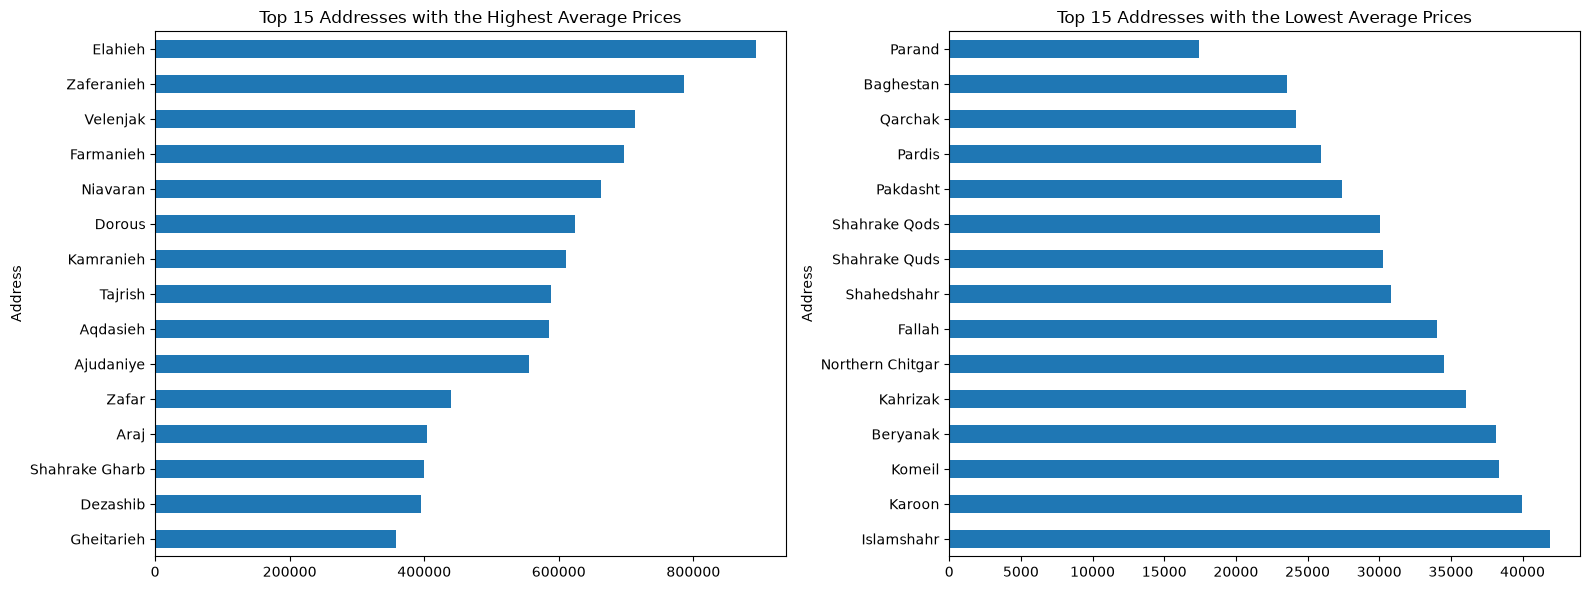

Total number of unique addresses: 192


In [13]:
top_addr = df.groupby('Address')[target].agg(['mean', 'count']).sort_values('mean', ascending=False)
top_addr = top_addr[top_addr['count'] >= 5]   # Keep only addresses with at least 5 samples

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_addr.head(15)['mean'].plot(kind='barh', ax=axes[0])
axes[0].set_title('Top 15 Addresses with the Highest Average Prices')
axes[0].invert_yaxis()

top_addr.tail(15)['mean'].plot(kind='barh', ax=axes[1])
axes[1].set_title('Top 15 Addresses with the Lowest Average Prices')

plt.tight_layout()
plt.show()

print("Total number of unique addresses:", df['Address'].nunique())

We observe a clear difference in the average house prices across different addresses. This indicates that Address is an informative feature and should be included in the model, as it is likely to contribute significantly to predicting house prices.

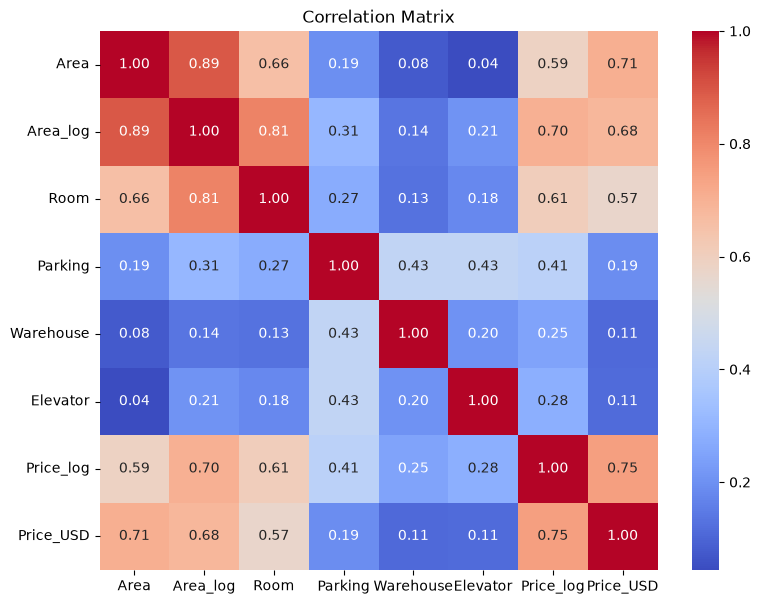

Price_USD    1.000000
Price_log    0.748352
Area         0.706721
Area_log     0.683543
Room         0.567599
Parking      0.190551
Elevator     0.111688
Warehouse    0.109987
Name: Price_USD, dtype: float64


In [14]:
corr_cols = ['Area', 'Area_log', 'Room', 'Parking', 'Warehouse', 'Elevator', 'Price_log',target]
df_corr = df[corr_cols].copy()

for col in boolean_cols:
    df_corr[col] = df_corr[col].astype(int)

plt.figure(figsize=(9,7))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

print(df_corr.corr()[target].sort_values(ascending=False))

From the correlation matrix, we can see that applying the log transformation improves the correlation between several features and the target variable. For example, the correlation between Parking and Price increases from 0.19 to 0.41 after transforming the target. Similar improvements are observed for Warehouse and Elevator.

However, the correlation between Area_log and Room exceeds 0.8, indicating a potential multicollinearity issue. Therefore, we should consider whether Room should be retained or removed from the model.

# Final Decision

Based on the analysis, we choose Price_log as the target variable.

For the input features, we use Area_log instead of the original Area. All other features are retained. Since Room may introduce multicollinearity, we will train and compare two versions of the model—one including Room and one excluding it—and select the model with the higher R² score.

In [15]:
df_clean = df[['Area_log', 'Room', 'Parking', 'Warehouse', 'Elevator', 'Address', 'Price_log']].copy()
df_clean.to_csv('../data/house_prices_clean.csv', index=False)